petal length (cm)    0.439994
petal width (cm)     0.421522
sepal length (cm)    0.108098
sepal width (cm)     0.030387
dtype: float64
Genauigkeit: 1.00


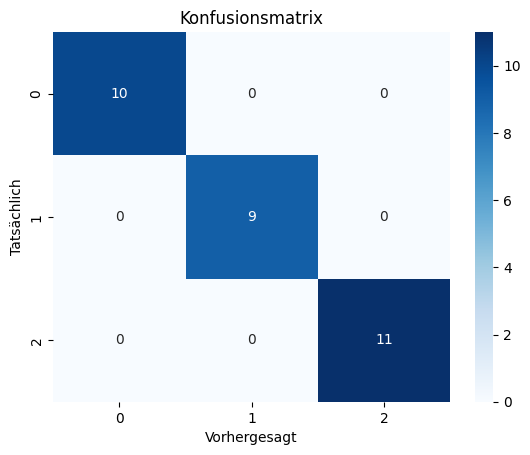

Sensitivität: 1.00
Spezifität: 1.00


In [23]:

import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))


from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Genauigkeit: {accuracy:.2f}")


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Konfusionsmatrix")
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.show()


TP = cm[0, 0]
FN = cm[0, 1:].sum()
FP = cm[1:, 0].sum()
TN = cm[1:, 1:].sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"Sensitivität: {sensitivity:.2f}")
print(f"Spezifität: {specificity:.2f}")




In [ ]:
## Zusammenfassung der Modellbewertung 
Mein Modell funktioniert sehr gut. Es hat alle Testdaten richtig erkannt – die Genauigkeit, Sensitivität und Spezifität sind jeweils 1.00. 
Ich denke, das liegt daran, dass sich die Klassen im Datensatz gut unterscheiden lassen. 
Besonders die Merkmale wie Blütenblatt-Länge und -Breite sind sehr aussagekräftig. 
Ausserdem habe ich den Random-Forest-Algorithmus verwendet, der zuverlässig und einfach zu nutzen ist.
Deshalb konnte das Modell so gute Ergebnisse liefern.